# **Assignment 7**
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

# **Part A** - Mandatory Exercises
Below you will find the mandatory exercises for Week 7 of the course Data Mining and Machine Learning.

## **Exercise 1** - AUC or Accuracy?

We explore the problem of class imbalance, and compare a classifier to randomly picking a label (which can be surprisingly effective in terms of accuracy!).

**a.** Based on the labels and probabilities below, calculate the AUC.  Additionally, calculate the AUC for a simple classifier that randomly guesses (in other words, assigns probability 0.5 to each data point).

If you wish, you can use the ```sklearn.metrics.roc_auc_score``` function to calculate the AUC.

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score

Labels = np.array([0,0,0,1,0,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1])
Classifier_1_probs = np.array([0.01,0.03,0.06,0.08,0.11,0.13,0.15,0.18,0.2,0.23,0.25,0.27,0.30,0.32,0.34,0.37,0.39,0.42,0.44,0.46,0.49,0.51,0.52,0.53,
0.54,0.56,0.58,0.61,0.63,0.66,0.68,0.7,0.73,0.75,0.77,0.8,0.82,0.85,0.87,0.89,0.92,0.94,0.97,0.99])

auc_score_Classifier_1 = roc_auc_score(Labels, Classifier_1_probs)
auc_score_Random_guessing = 0.5

print(auc_score_Classifier_1)

0.7743055555555556


**b.** Is Classifier 1 better or worse than the random guessing classifier in terms of AUC?

**ANSWER:** Classifier 1 is generally better than the random guessing classifier, since it has a higher AUC score.

**c.** Calculate the ROC curves for both of the classifiers by calculating the FP and TP rates and plot them in the same plot. Make the plot yourself as opposed to using a plotting library.

Hint: the function ```sklearn.metrics.roc_curve``` can be used for computing the FP and TP rates. You can then plot them using the ```matplotlib.pyplot``` plot function. Remember to include a legend.

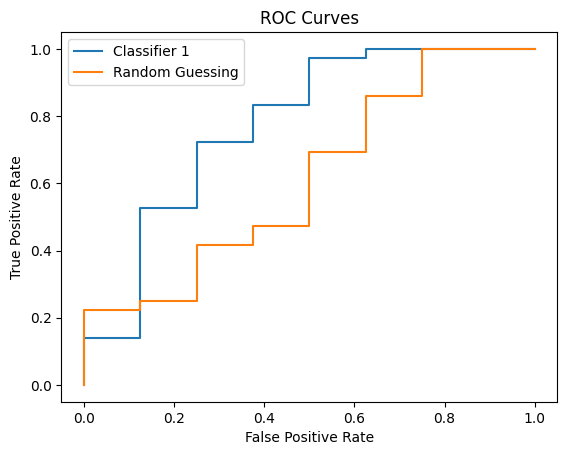

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(Labels, Classifier_1_probs)
fpr_random, tpr_random, _ = roc_curve(Labels, np.random.rand(len(Labels)))
plt.plot(fpr1, tpr1, label='Classifier 1')
plt.plot(fpr_random, tpr_random, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

**d.** We are now going to classify all points.  Set the threshold of both classifiers to 0.5. To be more precise: assign the predicted label to Class 1 if the predicted probability is equal to or larger than 0.5 and to Class 0 otherwise. Report the accuracies for both classifiers and report which one is largest.

In [18]:
threshold = 0.5
Classifier_1_predicted_labels = np.array([])
Random_guess_predicted_labels = np.array([])

correct = 0
wrong = 0
for i in range(len(Classifier_1_probs)):
    if Classifier_1_probs[i] >= threshold:
        if Labels[i] == 1:
            correct += 1
        else:
            wrong += 1
    else:
        if Labels[i] == 1:
            wrong += 1
        else:
            correct += 1
c1_accuracy = correct/(correct + wrong)

numer = 0
denom = 0

for j in Labels:
    if j == 1:
        numer += 1
    denom += 1
    
rand_accuracy = numer/denom
        

if c1_accuracy > rand_accuracy:
    print(f"classifier 1 accuracy: {c1_accuracy}, random classifier accuracy: {rand_accuracy}, better is classifier 1.")
if c1_accuracy < rand_accuracy:
    print(f"classifier 1 accuracy: {c1_accuracy}, random classifier accuracy: {rand_accuracy}, better is random classifier.")
if c1_accuracy == rand_accuracy:
    print(f"classifier 1 accuracy: {c1_accuracy}, random classifier accuracy: {rand_accuracy}, both classifiers are equal. :)")


classifier 1 accuracy: 0.6136363636363636, random classifier accuracy: 0.8181818181818182, better is random classifier.


**e.** Can you explain why the random guess model appears to be doing better in terms of accuracy than Classifier 1, even though it had a lower AUC? Does this mean that Classifier 1 is useless? Can you think of a situation where Classifier 1 might be more beneficial than always picking the same label?

**ANSWER:**

Since the random guess model appears to be doing better, we can deduce that the data is unbalanced. Our variable rand_accuracy actually tells us that 81 % of elements belong to class 1 and only 19 % of elements to class 0.

Classifier 1 might be more beneficial when we want to catch the observe the elements of class 0.

**f.** In a bit of a different scenario, you are advising a client about a classification model that differentiates between 2 classes in your dataset. The accuracy of the model in question is high (95%), however there is major class imbalance present in the dataset. You have tried to explain to your client that although the accuracy of the model seems high, it might not actually be that good.

You suggest to use the AUC to evaluate model performance. However, your client wants to receive the accuracy measure, and does not care one single bit about the AUC. What baseline do you compare the accuracy of your model to, in order to make sure that the model is at all useful?

**ANSWER:**

We can compare the accuracy of our model with accuracy of always of always picking the same label, since then we'll learn if our model is accurate only for one of the classes. If our model only accurately assigns every data from the majority class with the majority of elements, its accuracy will be (almost) the same as of the model that assigns all elements to the major class.

## **Exercise 2** - From the book!

Make Exercise 13 from Section 3.11.

#### ANSWER:
##### (a):
Based on the accuracies shown in Table 3.7 I would choose model $T_{100}$, since it seems that for A has better accuracy.

##### (b):
Since the classification accuracy of $T_{10}$ and $T_{100}$ don't differ much, I would choose $T_{10}$, since it's more consistent, so for unseen instances we can better predict what the accuracy would be, whereas for $T_{100}$ if would appear that it is overfitted on A since the accuracy on B is much lower. This means, that it is most likely to drop further if another set C is introduces (new instances).

## **Exercise 3** - ...and another one

Make Exercise 19 from Section 6.14.

Note that you can of course make ROCs using any tool you like.  However, it can be instructive to try make at least one ROC by hand.

![solution to the exercise 3 pt1](3ex_1.jpeg)

![solution to the exercise 3 pt2](3ex_2.jpeg)

# **Part B**

## **Exercise 4**
Make Exercise 12 from TSKK, Section 3.11.